# TSMC: three chronological stacking configurations

**Ready to run.** This notebook compares exactly three predefined stacks. It does not load the previous full-history fitted models to create historical training predictions. Base models are trained afresh at each historical cutoff, and the meta-models learn from their chronological out-of-fold (OOF) predictions.

The target remains next-trading-day unadjusted Close in USD, known only after that trading day closes. All meta inputs are **predicted dollar changes**, not raw predicted price levels. The final prediction is today's Close plus the meta-model's predicted change.

| Stack | Base models | Meta inputs | Meta-model |
|---|---|---|---|
| 1: diverse | SARIMA, LSTM, XGBoost | 3 predicted changes | StandardScaler → Ridge, alpha 10 |
| 2: neural | LSTM, FT-Transformer, XGBoost | 3 predicted changes | StandardScaler → Ridge, alpha 10 |
| 3: contextual | All four | 4 predicted changes + 3 context variables + 4 volatility interactions | Standardized X and y → Elastic Net, alpha 0.01, l1_ratio 0.5 |

Ridge weights are unconstrained: they can be negative and need not sum to one. The contextual stack can change effective forecast weights with observed volatility; it is not an online retrained trading strategy. Stacking does not guarantee improved generalization.

**Selection discipline:** fit five expanding OOF blocks inside training; fit the three meta-models on those OOF rows; select by external validation RMSE. Then regenerate five OOF blocks inside train + validation, refit only the selected meta configuration, fit final base models, and evaluate once on test. Initial 40% blocks provide fitting history and are never meta-training rows in that OOF pass.

**Bounded work:** 12 base-model bundles (5 training OOF + 1 validation + 5 final OOF + 1 test). Each bundle has one SARIMA fit, two fits per neural model (stopping search + historical refit), and two XGBoost fits: **84 base training jobs**, plus 3 selection meta-fits and 1 final meta-fit. These are chronological refits of four fixed specifications, not 84 hyperparameter candidates. Predictions are shared across stacks. Jobs run sequentially. GPU: LSTM, Transformer, XGBoost. CPU: SARIMA, meta-models, preprocessing, plotting. A full run can take several minutes or longer; soft per-neural-fit budgets are not an overall runtime guarantee.

**Research limitation:** base specifications were chosen during earlier project experiments, so historical OOF predictions are out-of-sample conditional on these now-fixed specifications, not a fully nested re-selection of all architectures. The external validation has already guided prior model choices, and part of the test period was previously inspected. This experiment remains exploratory; a new untouched period is needed for stronger confirmation.


## 1. Imports, fixed model definitions and chronology helpers

Use the project's Python environment with CUDA-enabled PyTorch and XGBoost >=2.0, Statsmodels, scikit-learn, pandas, NumPy, joblib, Matplotlib and Jupyter. The notebook does not install packages. All implementation code is embedded below; no previously saved model or helper-file import is required to run it.

Neural definitions match the existing notebooks: a 20-close LSTM (64 units, one layer) and a 35-column FT-Transformer (width 32, four heads, two layers, feed-forward width 64). Both add a learned correction to the scaled current Close. Dropout is 0.1. They train with AdamW at 0.001, weight decay 0.0001 and gradient clipping 1.0. The LSTM uses batches of 64; the Transformer uses 32.

Meta regressors use the agreed fixed penalties, with no grid search. MASE uses the same reference history within each reported comparison. Always-up accuracy and up/down/flat counts accompany direction accuracy.


In [1]:
import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
for variable in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS'):
    os.environ[variable] = '2'
"""Chronological stacking helpers; embedded in Stacking.ipynb by its builder.

No experiment runs at import. Every model is fitted afresh at its historical cutoff.
"""
import gc
import hashlib
import json
import random
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAXResults


BASE_NAMES = ['SARIMA', 'LSTM', 'FT_Transformer', 'XGBoost']
CURATED = ['Return_1D', 'Return_Lag_1', 'Return_Lag_5', 'High_Low_Range',
           'Open_Close_Change', 'Volatility_20', 'Momentum_5D', 'Volume']
STACKS = {
    'Stack_1_diverse_ridge': {'bases': ['SARIMA', 'LSTM', 'XGBoost'], 'meta': 'ridge'},
    'Stack_2_neural_ridge': {'bases': ['LSTM', 'FT_Transformer', 'XGBoost'], 'meta': 'ridge'},
    'Stack_3_context_elastic': {'bases': BASE_NAMES, 'meta': 'elastic'},
}
DEFAULT_SETTINGS = {
    'seed': 42, 'lookback': 20, 'internal_stopping_fraction': 0.15,
    'lstm_max_epochs': 40, 'lstm_patience': 6, 'lstm_seconds': 90.0,
    'transformer_max_epochs': 80, 'transformer_patience': 10, 'transformer_seconds': 900.0,
    'learning_rate': 0.001, 'weight_decay': 0.0001, 'dropout': 0.1,
    'gradient_clip': 1.0, 'min_delta': 1e-6,
    'xgb_max_rounds': 300, 'xgb_patience': 25, 'sarima_maxiter': 250,
    'sarima_order': (0, 1, 0), 'sarima_seasonal_order': (0, 1, 1, 5),
    'ridge_alpha': 10.0, 'elastic_alpha': 0.01, 'elastic_l1_ratio': 0.5,
}


class PriceCorrectionLSTM(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(64, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x, anchor):
        _, (hidden, _) = self.lstm(x)
        return anchor + self.head(self.dropout(hidden[-1])).squeeze(-1)


class CompactFTTransformer(nn.Module):
    def __init__(self, n_features, dropout=0.1):
        super().__init__()
        self.feature_weight = nn.Parameter(torch.empty(n_features, 32))
        self.feature_bias = nn.Parameter(torch.zeros(n_features, 32))
        self.summary_token = nn.Parameter(torch.zeros(1, 1, 32))
        nn.init.normal_(self.feature_weight, std=0.02)
        nn.init.normal_(self.summary_token, std=0.02)
        layer = nn.TransformerEncoderLayer(32, 4, dim_feedforward=64, dropout=dropout,
                                          activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(32)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(32, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x, anchor):
        tokens = x.unsqueeze(-1) * self.feature_weight + self.feature_bias
        tokens = torch.cat([self.summary_token.expand(len(x), -1, -1), tokens], dim=1)
        hidden = self.encoder(tokens)[:, 0]
        return anchor + self.head(self.dropout(self.norm(hidden))).squeeze(-1)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def check_chronology(fit, later):
    assert len(fit) and len(later)
    assert fit['Target_Date'].is_monotonic_increasing
    assert later['Target_Date'].is_monotonic_increasing
    assert fit['Target_Date'].max() < later['Target_Date'].min()
    # At the first prediction's close, this last fitting label is already observable.
    assert fit['Target_Date'].max() <= later['Origin_Date'].min()
    assert int(fit['Origin_Row'].max()) + 1 == int(later['Origin_Row'].min())


def expanding_blocks(frame, n_splits=5, initial_fraction=0.40):
    start = int(len(frame) * initial_fraction)
    edges = np.linspace(start, len(frame), n_splits + 1, dtype=int)
    assert start >= 100 and np.all(np.diff(edges) > 0)
    for fold, (left, right) in enumerate(zip(edges[:-1], edges[1:]), 1):
        fit, held = frame.iloc[:left].copy(), frame.iloc[left:right].copy()
        check_chronology(fit, held)
        yield fold, fit, held


def verify_xgb_gpu(model):
    device = json.loads(model.save_config())['learner']['generic_param']['device']
    if not device.startswith('cuda'):
        raise RuntimeError(f'CUDA training required; XGBoost used {device}.')
    return device


def score_prices(frame, prices, history):
    y = frame['Target_Close'].to_numpy(float)
    current = frame['Close'].to_numpy(float)
    prices = np.asarray(prices, dtype=float)
    assert prices.shape == y.shape and np.isfinite(prices).all()
    mae = float(mean_absolute_error(y, prices))
    mse = float(mean_squared_error(y, prices))
    baseline = float(np.sqrt(mean_squared_error(y, current)))
    scale = float(np.abs(history['Target_Close'] - history['Close']).mean())
    assert baseline > 0 and scale > 0
    direction = np.sign(prices - current)
    actual_direction = np.sign(y - current)
    return {'MAE': mae, 'MSE': mse, 'RMSE': float(np.sqrt(mse)),
            'MAPE_pct': float(np.mean(np.abs((y - prices) / y)) * 100),
            'R2': float(r2_score(y, prices)), 'MASE': mae / scale,
            'RMSE_skill_pct': float((1 - np.sqrt(mse) / baseline) * 100),
            'Direction_accuracy_pct': float(np.mean(direction == actual_direction) * 100),
            'Always_up_accuracy_pct': float(np.mean(actual_direction > 0) * 100),
            'Predicted_up': int(np.sum(direction > 0)),
            'Predicted_down': int(np.sum(direction < 0)), 'Predicted_flat': int(np.sum(direction == 0))}


## 2. Leakage-aware base-model training

Each historical fitting block reserves its last 15% as an internal stopping period. Neural epochs and XGBoost rounds are selected there, then fresh models/scalers are fitted on the entire historical block for the locked duration. No held-out OOF/validation/test target chooses the duration of its own base model.

* SARIMA `(0,1,0) × (0,1,1,5)`, no drift, is fitted once per block on Close targets; each prediction precedes its actual-value state update. Earlier actuals in the same held block may inform later forecasts. Coefficients are not refitted daily. Lag 5 means five observed trading rows, not exact weekdays.
* LSTM uses 20 past/current closes; its scaler uses only input history available in its fitting block. Its initial window can use earlier raw Close observations because those values were already known.
* FT-Transformer uses the existing 35 features (exclude Date, Adj Close, Year); scaling and the log1p Volume transform match the original neural preprocessing.
* XGBoost uses the eight curated features, depth 2, eta 0.03, min_child_weight 10, lambda 10, subsample 0.8, max_bin 128, up to 300 rounds with patience 25. It directly learns the dollar change; no scaler is needed.

LSTM stopping: up to 40 epochs, patience 6, 90-second soft search budget. Transformer: up to 80 epochs, patience 10, 900-second soft search budget. Each full-block refit is additional. Seed is fixed at 42. Failures stop the experiment, rather than silently removing a base model or falling back to CPU. Each completed bundle saves its models, preprocessing, stopping curves, warning/convergence records and training boundaries.


In [2]:
class BaseEngine:
    def __init__(self, raw, transformer_features, settings=None):
        self.raw = raw
        self.features = list(transformer_features)
        self.settings = {**DEFAULT_SETTINGS, **(settings or {})}
        if not torch.cuda.is_available():
            raise RuntimeError('CUDA-enabled PyTorch and an NVIDIA GPU are required.')
        if int(xgb.__version__.split('.')[0]) < 2:
            raise RuntimeError('CUDA-enabled XGBoost >=2.0 is required.')
        self.device = torch.device('cuda:0')

    def _matrix(self, frame, labels=False):
        x = frame[CURATED].to_numpy(np.float32)
        assert np.isfinite(x).all()
        y = (frame['Target_Close'] - frame['Close']).to_numpy(np.float32) if labels else None
        return xgb.DMatrix(x, label=y, feature_names=CURATED, nthread=2)

    def _values(self, frame, columns):
        x = frame[columns].astype(float).copy()
        if 'Volume' in columns:
            x['Volume'] = np.log1p(x['Volume'])
        return x.to_numpy()

    def _preprocessing(self, name, frame):
        columns = ['Close'] if name == 'LSTM' else self.features
        if name == 'LSTM':
            first = int(frame['Origin_Row'].min()) - self.settings['lookback'] + 1
            last = int(frame['Origin_Row'].max())
            assert first >= 0
            input_rows = self.raw.iloc[first:last + 1]
        else:
            input_rows = frame
        return {'features': columns, 'x_scaler': StandardScaler().fit(self._values(input_rows, columns)),
                'y_scaler': StandardScaler().fit(frame[['Target_Close']].to_numpy()),
                'fit_last_target': str(frame['Target_Date'].max()),
                'fit_last_origin': str(frame['Origin_Date'].max())}

    def _arrays(self, name, frame, prep):
        if name == 'LSTM':
            origins = frame['Origin_Row'].to_numpy(int)
            offsets = np.arange(self.settings['lookback'] - 1, -1, -1)
            indices = origins[:, None] - offsets[None, :]
            assert indices.min() >= 0 and np.all(indices[:, -1] == origins)
            x = self.raw['Close'].to_numpy()[indices]
            x = prep['x_scaler'].transform(x.reshape(-1, 1)).reshape(*indices.shape, 1)
        else:
            x = prep['x_scaler'].transform(self._values(frame, prep['features']))
        anchor = prep['y_scaler'].transform(frame[['Close']].to_numpy()).reshape(-1)
        assert np.isfinite(x).all() and np.isfinite(anchor).all()
        return x.astype(np.float32), anchor.astype(np.float32)

    def _loader(self, name, frame, prep, labels=False, shuffle=False):
        x, anchor = self._arrays(name, frame, prep)
        arrays = [torch.from_numpy(x), torch.from_numpy(anchor)]
        if labels:
            y = prep['y_scaler'].transform(frame[['Target_Close']].to_numpy()).reshape(-1)
            arrays.append(torch.from_numpy(y.astype(np.float32)))
        return DataLoader(TensorDataset(*arrays), batch_size=64 if name == 'LSTM' else 32,
                          shuffle=shuffle, num_workers=0,
                          generator=torch.Generator().manual_seed(self.settings['seed']))

    def _new_neural(self, name):
        seed_everything(self.settings['seed'])
        model = (PriceCorrectionLSTM(self.settings['dropout']) if name == 'LSTM'
                 else CompactFTTransformer(len(self.features), self.settings['dropout']))
        return model.to(self.device)

    def _epoch(self, model, loader, optimizer=None):
        model.train(optimizer is not None)
        total, count = 0.0, 0
        with torch.set_grad_enabled(optimizer is not None):
            for x, anchor, y in loader:
                x, anchor, y = x.to(self.device), anchor.to(self.device), y.to(self.device)
                if optimizer is not None:
                    optimizer.zero_grad(set_to_none=True)
                loss = ((model(x, anchor) - y) ** 2).mean()
                if not torch.isfinite(loss):
                    raise RuntimeError('Non-finite neural loss.')
                if optimizer is not None:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), self.settings['gradient_clip'])
                    optimizer.step()
                total += float(loss.detach()) * len(y)
                count += len(y)
        return total / count

    def _optimizer(self, model):
        return torch.optim.AdamW(model.parameters(), lr=self.settings['learning_rate'],
                                 weight_decay=self.settings['weight_decay'])

    def _fit_neural(self, name, fit, inner, stopping, directory):
        prefix = 'lstm' if name == 'LSTM' else 'transformer'
        prep = self._preprocessing(name, inner)
        train_loader = self._loader(name, inner, prep, True, name != 'LSTM')
        stop_loader = self._loader(name, stopping, prep, True)
        model = self._new_neural(name)
        optimizer = self._optimizer(model)
        best, reference, best_epoch, stale = float('inf'), float('inf'), 0, 0
        curve, reason, started = [], 'max_epochs', time.perf_counter()
        for epoch in range(1, self.settings[prefix + '_max_epochs'] + 1):
            train_loss = self._epoch(model, train_loader, optimizer)
            stop_loss = self._epoch(model, stop_loader)
            curve.append({'epoch': epoch, 'train_MSE': train_loss, 'stopping_MSE': stop_loss})
            if stop_loss < best:
                best, best_epoch = stop_loss, epoch
            if stop_loss < reference - self.settings['min_delta']:
                reference, stale = stop_loss, 0
            else:
                stale += 1
            if stale >= self.settings[prefix + '_patience']:
                reason = 'early_stopping'
                break
            if time.perf_counter() - started >= self.settings[prefix + '_seconds']:
                reason = 'time_budget'
                break
        assert best_epoch > 0
        pd.DataFrame(curve).to_csv(directory / f'{name}_learning_curve.csv', index=False)
        del model, optimizer, train_loader, stop_loader
        gc.collect()
        torch.cuda.empty_cache()
        # Refit fresh weights/scalers on the complete historical fitting block.
        prep = self._preprocessing(name, fit)
        model = self._new_neural(name)
        optimizer = self._optimizer(model)
        loader = self._loader(name, fit, prep, True, name != 'LSTM')
        for _ in range(best_epoch):
            self._epoch(model, loader, optimizer)
        model.eval()
        torch.save({'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
                    'name': name, 'epochs': best_epoch}, directory / f'{name}.pt')
        joblib.dump(prep, directory / f'{name}_preprocessing.joblib')
        model = model.to('cpu')
        del optimizer, loader
        torch.cuda.empty_cache()
        return (model, prep), {'epochs': best_epoch, 'epochs_tried': len(curve),
                               'stopping_reason': reason, 'training_device': str(self.device)}

    def fit_bundle(self, fit, directory):
        directory = Path(directory)
        directory.mkdir(parents=True, exist_ok=False)
        cut = int(len(fit) * (1 - self.settings['internal_stopping_fraction']))
        inner, stopping = fit.iloc[:cut], fit.iloc[cut:]
        check_chronology(inner, stopping)
        metadata = {'fit_rows': len(fit), 'fit_last_target': str(fit['Target_Date'].max()),
                    'inner_last_target': str(inner['Target_Date'].max()),
                    'stopping_first_origin': str(stopping['Origin_Date'].min()),
                    'stopping_last_target': str(stopping['Target_Date'].max()),
                    'settings': self.settings, 'transformer_features': self.features, 'models': {}}
        bundle = {}
        try:
            started = time.perf_counter()
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                sarima = SARIMAX(fit['Target_Close'].to_numpy(),
                                 order=self.settings['sarima_order'],
                                 seasonal_order=self.settings['sarima_seasonal_order'], trend='n',
                                 enforce_stationarity=True, enforce_invertibility=True).fit(
                                     disp=False, maxiter=self.settings['sarima_maxiter'], cov_type='none')
            metadata['models']['SARIMA'] = {'warnings': [str(w.message) for w in caught],
                                            'seconds': time.perf_counter() - started,
                                            'converged': bool(sarima.mle_retvals.get('converged', False))}
            if not metadata['models']['SARIMA']['converged'] or not np.isfinite(sarima.params).all():
                raise RuntimeError('SARIMA failed to converge; no silent model substitution.')
            sarima.save(directory / 'SARIMA.pkl')
            bundle['SARIMA'] = sarima
            for name in ['LSTM', 'FT_Transformer']:
                started = time.perf_counter()
                print(f'  {directory.name}: fitting {name}', flush=True)
                bundle[name], metadata['models'][name] = self._fit_neural(name, fit, inner, stopping, directory)
                metadata['models'][name]['seconds'] = time.perf_counter() - started
            params = dict(objective='reg:squarederror', eval_metric='rmse', tree_method='hist',
                          device='cuda:0', nthread=2, seed=self.settings['seed'], base_score=0.0,
                          max_depth=2, eta=0.03, min_child_weight=10, reg_lambda=10.0,
                          reg_alpha=0.0, subsample=0.8, colsample_bytree=1.0, max_bin=128)
            curves = {}
            tuned = xgb.train(params, self._matrix(inner, True),
                              num_boost_round=self.settings['xgb_max_rounds'],
                              evals=[(self._matrix(stopping, True), 'stopping')],
                              early_stopping_rounds=self.settings['xgb_patience'],
                              evals_result=curves, verbose_eval=False)
            verify_xgb_gpu(tuned)
            rounds = int(tuned.best_iteration + 1)
            del tuned
            booster = xgb.train(params, self._matrix(fit, True), num_boost_round=rounds)
            metadata['models']['XGBoost'] = {'rounds': rounds, 'parameters': params,
                                            'training_device': verify_xgb_gpu(booster)}
            pd.DataFrame(curves['stopping']).to_csv(directory / 'XGBoost_stopping_curve.csv', index=False)
            booster.save_model(directory / 'XGBoost.ubj')
            bundle['XGBoost'] = booster
            metadata['status'] = 'complete'
            return bundle
        except Exception as exc:
            metadata.update(status='failed', error=f'{type(exc).__name__}: {exc}')
            raise
        finally:
            (directory / 'fit_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

    def predict_bundle(self, bundle, frame):
        predictions = pd.DataFrame(index=frame.index)
        state, values = bundle['SARIMA'], []
        for actual in frame['Target_Close'].to_numpy():
            values.append(float(np.asarray(state.forecast(1)).reshape(-1)[0]))
            # Only AFTER the prediction can its actual target update the state.
            state = state.extend(np.array([actual]))
        predictions['SARIMA'] = np.asarray(values) - frame['Close'].to_numpy()
        for name in ['LSTM', 'FT_Transformer']:
            model, prep = bundle[name]
            model.to(self.device).eval()
            output = []
            with torch.no_grad():
                for x, anchor in self._loader(name, frame, prep):
                    output.append(model(x.to(self.device), anchor.to(self.device)).cpu().numpy())
            scaled_prices = np.concatenate(output).reshape(-1, 1)
            prices = prep['y_scaler'].inverse_transform(scaled_prices).reshape(-1)
            predictions[name] = prices.astype(float) - frame['Close'].to_numpy()
            model.to('cpu')
        predictions['XGBoost'] = bundle['XGBoost'].predict(self._matrix(frame)).astype(float)
        assert np.isfinite(predictions.to_numpy()).all()
        torch.cuda.empty_cache()
        return predictions[BASE_NAMES]

    def load_bundle(self, directory):
        directory = Path(directory)
        metadata = json.loads((directory / 'fit_metadata.json').read_text())
        if metadata['status'] != 'complete':
            raise RuntimeError('Cannot load an incomplete base bundle.')
        if metadata['settings'] != json.loads(json.dumps(self.settings)) or metadata['transformer_features'] != self.features:
            raise ValueError('Engine configuration must match saved bundle metadata.')
        bundle = {'SARIMA': SARIMAXResults.load(directory / 'SARIMA.pkl')}
        for name in ['LSTM', 'FT_Transformer']:
            model = self._new_neural(name)
            saved = torch.load(directory / f'{name}.pt', map_location='cpu', weights_only=True)
            model.load_state_dict(saved['state_dict'])
            bundle[name] = (model.cpu().eval(), joblib.load(directory / f'{name}_preprocessing.joblib'))
        booster = xgb.Booster()
        booster.load_model(directory / 'XGBoost.ubj')
        booster.set_param({'device': 'cuda:0', 'nthread': 2})
        bundle['XGBoost'] = booster
        return bundle


## 3. Shared OOF predictions and meta-model definitions

The manual expanding-block loop avoids random folds and does not assign artificial OOF predictions to the initial history block. Date/index assertions enforce row alignment. Models in later folds can train on earlier folds' realized outcomes, as would be possible chronologically.

Stack 3 adds Volatility_20, Momentum_5D and Close/SMA_20 − 1, plus each predicted change multiplied by Volatility_20. These 11 features use only origin-day information. Input and target scalers fit only on meta-training OOF rows; transformations are preserved for later predictions. Elastic Net convergence failures are errors.


In [3]:
def build_oof(engine, frame, directory, n_splits=5):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=False)
    blocks, audits = [], []
    for fold, fit, held in expanding_blocks(frame, n_splits):
        print(f'OOF fold {fold}/{n_splits}: {len(fit)} fit -> {len(held)} predictions', flush=True)
        fold_dir = directory / f'fold_{fold}'
        bundle = engine.fit_bundle(fit, fold_dir)
        predictions = engine.predict_bundle(bundle, held)
        export = held[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].join(predictions)
        export.to_csv(fold_dir / 'oof_predictions.csv', index=False)
        blocks.append(predictions)
        audits.append({'fold': fold, 'fit_rows': len(fit), 'held_rows': len(held),
                       'fit_last_target': fit['Target_Date'].max(),
                       'held_first_origin': held['Origin_Date'].min(),
                       'held_first_target': held['Target_Date'].min(),
                       'held_last_target': held['Target_Date'].max()})
        pd.DataFrame(audits).to_csv(directory / 'fold_audit.csv', index=False)
        del bundle
        gc.collect()
        torch.cuda.empty_cache()
    result = pd.concat(blocks)
    assert result.index.is_unique and result.index.is_monotonic_increasing
    assert len(result) == len(frame) - int(0.40 * len(frame))
    frame.loc[result.index, ['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].join(result).to_csv(
        directory / 'oof_predictions.csv', index=False)
    return result


def meta_inputs(name, base_changes, frame):
    assert frame.index.equals(base_changes.index), 'Meta rows must match exactly.'
    spec = STACKS[name]
    values = base_changes[spec['bases']].copy()
    if spec['meta'] == 'elastic':
        values['Volatility_20'] = frame['Volatility_20']
        values['Momentum_5D'] = frame['Momentum_5D']
        values['Trend_distance'] = frame['Close'] / frame['SMA_20'] - 1
        for base in spec['bases']:
            values[base + '_x_volatility'] = base_changes[base] * frame['Volatility_20']
    assert np.isfinite(values.to_numpy()).all()
    assert values.shape[1] == (11 if spec['meta'] == 'elastic' else 3)
    return values


def fit_meta(name, base_changes, frame, settings=None):
    settings = {**DEFAULT_SETTINGS, **(settings or {})}
    x = meta_inputs(name, base_changes, frame)
    y = (frame['Target_Close'] - frame['Close']).to_numpy()
    if STACKS[name]['meta'] == 'ridge':
        model = make_pipeline(StandardScaler(), Ridge(alpha=settings['ridge_alpha'], fit_intercept=True))
    else:
        regression = make_pipeline(StandardScaler(), ElasticNet(
            alpha=settings['elastic_alpha'], l1_ratio=settings['elastic_l1_ratio'],
            fit_intercept=True, max_iter=10000, tol=1e-4, selection='cyclic'))
        model = TransformedTargetRegressor(regressor=regression, transformer=StandardScaler())
    with warnings.catch_warnings():
        warnings.simplefilter('error', ConvergenceWarning)
        model.fit(x, y)
    return model


def meta_prices(name, model, base_changes, frame):
    return frame['Close'].to_numpy() + model.predict(meta_inputs(name, base_changes, frame))


def coefficient_table(name, model):
    pipeline = model.regressor_ if STACKS[name]['meta'] == 'elastic' else model
    scaler, linear = pipeline.steps[0][1], pipeline.steps[-1][1]
    # Translate coefficients back to original input and dollar-change units.
    y_scale = float(model.transformer_.scale_[0]) if STACKS[name]['meta'] == 'elastic' else 1.0
    y_mean = float(model.transformer_.mean_[0]) if STACKS[name]['meta'] == 'elastic' else 0.0
    weights = linear.coef_ * y_scale / scaler.scale_
    intercept = y_mean + float(linear.intercept_) * y_scale - float(np.dot(weights, scaler.mean_))
    return pd.DataFrame({'feature': [*scaler.feature_names_in_, 'Intercept'],
                         'coefficient_original_units': [*weights, intercept]})


## 4. Run configuration and source-data audit

Use the same local master CSV and causal indicator checks as the previous notebooks. Exclude Adj Close from modeling because point-in-time adjustment provenance is unavailable. Source checks establish local consistency, not independent vendor authenticity. No warm-up values are backfilled.

The run directory is unique. Intermediate fits are saved for inspection, but this notebook does not automatically resume partially completed runs. `latest_run.json` is updated only after final verification and reporting complete.


In [4]:
from datetime import datetime, timezone
import platform
import sklearn
import statsmodels
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

torch.set_num_threads(2)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
if not torch.cuda.is_available():
    raise RuntimeError('Select the CUDA-enabled project kernel before running this notebook.')

SETTINGS = dict(DEFAULT_SETTINGS)
N_SPLITS = 5
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'Data' / 'TSMC_Master_Features_15Y.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Start Jupyter within the project containing Data/TSMC_Master_Features_15Y.csv.')
DATA_FILE = ROOT / 'Data' / 'TSMC_Master_Features_15Y.csv'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN_DIR = ROOT / 'models' / 'stacking' / RUN_ID
PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=False)
SOURCE_HASH = hashlib.sha256(DATA_FILE.read_bytes()).hexdigest()
plt.style.use('seaborn-v0_8-whitegrid')

def finish_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', dpi=140, bbox_inches='tight')
    plt.show()
    plt.close()

print('GPU:', torch.cuda.get_device_name(0), '| PyTorch:', torch.__version__, '| XGBoost:', xgb.__version__)
print('Outputs:', RUN_DIR)


GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU | PyTorch: 2.11.0+cu128 | XGBoost: 3.2.0
Outputs: f:\SEM-7\Time Series Analysis\Project\models\stacking\20260927T042412093647Z


In [5]:
raw = pd.read_csv(DATA_FILE)
raw['Date'] = pd.to_datetime(raw['Date'], errors='raise')
raw = raw.sort_values('Date').reset_index(drop=True)
assert raw['Date'].notna().all() and raw['Date'].is_unique, 'Missing or duplicate dates.'
assert raw['Date'].is_monotonic_increasing
numeric_columns = raw.columns.drop('Date').tolist()
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='raise')
assert not np.isinf(raw[numeric_columns].to_numpy()).any(), 'Infinite data values.'
assert (raw['Close'] > 0).all() and (raw['Volume'] >= 0).all()
tol = 1e-5
assert (raw['High'] + tol >= raw[['Open', 'Close', 'Low']].max(axis=1)).all()
assert (raw['Low'] - tol <= raw[['Open', 'Close', 'High']].min(axis=1)).all()

expected = {
    'Log_Close': np.log(raw['Close']),
    'Return_1D': raw['Close'].pct_change(fill_method=None),
    'Log_Return_1D': np.log(raw['Close']).diff(),
    'High_Low_Range': (raw['High'] - raw['Low']) / raw['Close'],
    'Open_Close_Change': (raw['Close'] - raw['Open']) / raw['Open'],
    'Day_of_Week': raw['Date'].dt.dayofweek,
    'Month': raw['Date'].dt.month, 'Quarter': raw['Date'].dt.quarter,
    'Year': raw['Date'].dt.year,
}
for lag in [1, 2, 3, 5, 10, 20]:
    expected[f'Close_Lag_{lag}'] = raw['Close'].shift(lag)
    expected[f'Return_Lag_{lag}'] = expected['Return_1D'].shift(lag)
for window in [5, 10, 20, 50]:
    expected[f'SMA_{window}'] = raw['Close'].rolling(window).mean()
for window in [5, 10, 20]:
    expected[f'Volatility_{window}'] = expected['Log_Return_1D'].rolling(window).std()
    expected[f'Momentum_{window}D'] = raw['Close'].pct_change(window, fill_method=None)
for name, values in expected.items():
    np.testing.assert_allclose(raw[name], values, rtol=1e-6, atol=1e-8,
                               equal_nan=True, err_msg=f'Feature mismatch: {name}')

audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()})
display(audit)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; '
      f"{raw['Date'].min().date()} through {raw['Date'].max().date()}")
print('Verified all engineered columns against causal trailing calculations.')
audit.to_csv(RUN_DIR / 'data_audit.csv')


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0
Log_Close,float64,0
Return_1D,float64,1
Log_Return_1D,float64,1


3,771 rows; 38 columns; 2011-09-12 through 2026-09-10
Verified all engineered columns against causal trailing calculations.


## 5. Preserve the common forecast dates

All feature sets share the original completeness filter and 70%/15%/15% target-date split. The 20-close windows use only rows ending at their own origin. All four base forecasts use the same meta-training rows and the same external evaluation dates.

For the current file, expect 2,604 training, 558 validation and 559 test targets. The data-dependent assertions below also support a future extended dataset. Saved split tables record the actual dates used.


In [6]:
numeric_features = [c for c in numeric_columns if c != 'Adj Close']
TRANSFORMER_FEATURES = [c for c in numeric_features if c != 'Year']
assert len(TRANSFORMER_FEATURES) == 35
raw['Origin_Row'] = np.arange(len(raw))
aligned = raw.rename(columns={'Date': 'Origin_Date'}).copy()
aligned['Target_Date'] = aligned['Origin_Date'].shift(-1)
aligned['Target_Close'] = aligned['Close'].shift(-1)
data = aligned.dropna(subset=numeric_features + ['Target_Date', 'Target_Close']).reset_index(drop=True)
assert data['Target_Date'].is_unique and data['Target_Date'].is_monotonic_increasing
assert (data['Origin_Date'] < data['Target_Date']).all()
assert data['Origin_Row'].min() >= SETTINGS['lookback'] - 1
assert np.all(np.diff(data['Origin_Row']) == 1), 'Unexpected interior missing rows; investigate before fitting SARIMA.'
train_end, validation_end = int(len(data) * 0.70), int(len(data) * 0.85)
train, validation, test = data.iloc[:train_end].copy(), data.iloc[train_end:validation_end].copy(), data.iloc[validation_end:].copy()
check_chronology(train, validation)
check_chronology(validation, test)
split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame), 'first_target': frame['Target_Date'].min(),
     'last_target': frame['Target_Date'].max()}
    for name, frame in [('train', train), ('validation', validation), ('test', test)]])
split_summary.to_csv(RUN_DIR / 'splits.csv', index=False)
display(split_summary)
engine = BaseEngine(raw, TRANSFORMER_FEATURES, SETTINGS)
fold_preview = pd.DataFrame([
    {'fold': fold, 'fit_rows': len(fit), 'OOF_rows': len(held),
     'fit_last_target': fit['Target_Date'].max(), 'OOF_first_origin': held['Origin_Date'].min(),
     'OOF_first_target': held['Target_Date'].min(), 'OOF_last_target': held['Target_Date'].max()}
    for fold, fit, held in expanding_blocks(train, N_SPLITS)])
display(fold_preview)


,split,rows,first_target,last_target
0,train,2604,2011-11-21,2022-03-28
1,validation,558,2022-03-29,2024-06-17
2,test,559,2024-06-18,2026-09-10


,fold,fit_rows,OOF_rows,fit_last_target,OOF_first_origin,OOF_first_target,OOF_last_target
0,1,1041,312,2016-01-12,2016-01-12,2016-01-13,2017-04-07
1,2,1353,313,2017-04-07,2017-04-07,2017-04-10,2018-07-06
2,3,1666,312,2018-07-06,2018-07-06,2018-07-09,2019-10-02
3,4,1978,313,2019-10-02,2019-10-02,2019-10-03,2020-12-29
4,5,2291,313,2020-12-29,2020-12-29,2020-12-30,2022-03-28


## 6. Generate the five training OOF blocks

This is the first substantial training step. One shared prediction table supplies all three meta-models. OOF scores are descriptive diagnostics only; no base specification is changed in response to them. The initial 40% history block is excluded from meta-training because it has no earlier fitted model to supply OOF forecasts.


In [7]:
train_oof = build_oof(engine, train, RUN_DIR / 'training_oof', N_SPLITS)
meta_train_frame = train.loc[train_oof.index]
oof_metrics = pd.DataFrame({
    name: score_prices(meta_train_frame, meta_train_frame['Close'].to_numpy() + train_oof[name].to_numpy(), train)
    for name in BASE_NAMES}).T
oof_metrics.to_csv(RUN_DIR / 'oof_base_diagnostics.csv')
display(oof_metrics[['RMSE', 'MAE', 'RMSE_skill_pct', 'Direction_accuracy_pct']])
print('Meta-training rows:', len(train_oof))


OOF fold 1/5: 1041 fit -> 312 predictions
  fold_1: fitting LSTM
  fold_1: fitting FT_Transformer


f:\Programs\PYTHON_310\lib\site-packages\torch\autograd\graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\attention_backward.cu:902.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


OOF fold 2/5: 1353 fit -> 313 predictions
  fold_2: fitting LSTM
  fold_2: fitting FT_Transformer
OOF fold 3/5: 1666 fit -> 312 predictions
  fold_3: fitting LSTM
  fold_3: fitting FT_Transformer
OOF fold 4/5: 1978 fit -> 313 predictions
  fold_4: fitting LSTM
  fold_4: fitting FT_Transformer
OOF fold 5/5: 2291 fit -> 313 predictions
  fold_5: fitting LSTM
  fold_5: fitting FT_Transformer


,RMSE,MAE,RMSE_skill_pct,Direction_accuracy_pct
SARIMA,1.483781,0.884362,-0.322650,51.887396
LSTM,1.484447,0.885445,-0.367678,50.927703
FT_Transformer,1.485738,0.902659,-0.454918,45.873321
XGBoost,1.474778,0.878459,0.286070,52.975048


Meta-training rows: 1563


## 7. Fit three meta-models and evaluate external validation

Fit each meta-model on the training OOF rows. Fit the four base specifications once on the full training period, with stopping duration still chosen internally, then generate external validation forecasts. Those same forecasts are used by all three stacks and the reference strategies.

Select the stack with lowest validation RMSE, then MAE, then name. Also lock the best individual base model by validation RMSE for later comparison. Equal-weight averages have no learned meta weights; show one for each stack's base pool. Persistence remains mandatory. A stack is not declared useful merely because it wins among stacks.


In [8]:
selection_meta = {name: fit_meta(name, train_oof, meta_train_frame, SETTINGS) for name in STACKS}
validation_bundle = engine.fit_bundle(train, RUN_DIR / 'validation_bases')
validation_base = engine.predict_bundle(validation_bundle, validation)
validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].join(validation_base).to_csv(
    RUN_DIR / 'validation_base_changes.csv', index=False)
validation_prices = {'Persistence': validation['Close'].to_numpy()}
for name in BASE_NAMES:
    validation_prices[name] = validation['Close'].to_numpy() + validation_base[name].to_numpy()
for name, spec in STACKS.items():
    validation_prices[name] = meta_prices(name, selection_meta[name], validation_base, validation)
    validation_prices['Mean_' + name] = (validation['Close'].to_numpy()
                                        + validation_base[spec['bases']].mean(axis=1).to_numpy())
    joblib.dump(selection_meta[name], RUN_DIR / f'{name}_validation_meta.joblib')
    coefficient_table(name, selection_meta[name]).to_csv(RUN_DIR / f'{name}_validation_coefficients.csv', index=False)

validation_metrics = pd.DataFrame({name: score_prices(validation, p, train)
                                    for name, p in validation_prices.items()}).T
validation_metrics.index.name = 'model'
validation_metrics.to_csv(RUN_DIR / 'validation_metrics.csv')
ranking = validation_metrics.loc[list(STACKS)].reset_index().sort_values(['RMSE', 'MAE', 'model'])
SELECTED_STACK = str(ranking.iloc[0]['model'])
BEST_BASE = str(validation_metrics.loc[BASE_NAMES].reset_index().sort_values(['RMSE', 'MAE', 'model']).iloc[0]['model'])
locked = {'selected_stack': SELECTED_STACK, 'best_individual_base': BEST_BASE,
          'selection': 'Validation RMSE, MAE, model name; no test-based changes',
          'stack_specification': STACKS[SELECTED_STACK]}
(RUN_DIR / 'locked_selection.json').write_text(json.dumps(locked, indent=2), encoding='utf-8')
validation_export = validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
for name, prices in validation_prices.items():
    validation_export[name] = prices
validation_export.to_csv(RUN_DIR / 'validation_predictions.csv', index=False)
display(validation_metrics.sort_values('RMSE'))
print('Locked stack:', SELECTED_STACK, '| locked individual reference:', BEST_BASE)
print('Selected stack beats validation persistence:',
      validation_metrics.loc[SELECTED_STACK, 'RMSE'] < validation_metrics.loc['Persistence', 'RMSE'])
del validation_bundle
gc.collect()
torch.cuda.empty_cache()


  validation_bases: fitting LSTM
  validation_bases: fitting FT_Transformer


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,RMSE_skill_pct,Direction_accuracy_pct,Always_up_accuracy_pct,Predicted_up,Predicted_down,Predicted_flat
model,,,,,,,,,,,,
LSTM,1.613475,4.968701,2.229058,1.630815,0.990262,2.615811,0.116507,47.670251,47.670251,558.0,0.0,0.0
SARIMA,1.611700,4.977256,2.230977,1.628121,0.990245,2.612934,0.030554,48.028674,47.670251,334.0,224.0,0.0
Persistence,1.607186,4.980299,2.231658,1.622008,0.990239,2.605615,0.000000,0.179211,47.670251,0.0,0.0,558.0
Mean_Stack_3_context_elastic,1.608494,4.981399,2.231905,1.624612,0.990237,2.607735,-0.011042,48.566308,47.670251,489.0,69.0,0.0
Mean_Stack_1_diverse_ridge,1.609543,4.982489,2.232149,1.626329,0.990235,2.609436,-0.021983,48.207885,47.670251,497.0,61.0,0.0
FT_Transformer,1.606010,4.983543,2.232385,1.620257,0.990233,2.603708,-0.032559,52.329749,47.670251,1.0,557.0,0.0
Mean_Stack_2_neural_ridge,1.607821,4.984966,2.232704,1.623963,0.990230,2.606644,-0.046840,49.103943,47.670251,482.0,76.0,0.0
XGBoost,1.609835,5.024557,2.241552,1.628119,0.990153,2.609909,-0.443349,49.820789,47.670251,406.0,152.0,0.0
Stack_2_neural_ridge,1.618387,5.091932,2.256531,1.640695,0.990021,2.623773,-1.114532,49.820789,47.670251,372.0,186.0,0.0


Locked stack: Stack_2_neural_ridge | locked individual reference: LSTM
Selected stack beats validation persistence: False


## 8. Rebuild OOF predictions on train + validation and refit the locked stack

Regenerate five expanding blocks using the complete historical 85% period. Keep the selected stack structure and meta penalties unchanged. Fit the final meta-model on these new OOF predictions, never on in-sample predictions from the final base models.

Refit all four base specifications on the historical 85% so the final comparison can also report the previously selected individual model and equal-weight references. All base specifications remain fixed. Save final models before test state updates. Meta weights are fixed during test; contextual inputs can still vary at each origin.


In [9]:
history = pd.concat([train, validation])
final_oof = build_oof(engine, history, RUN_DIR / 'final_oof', N_SPLITS)
final_meta_frame = history.loc[final_oof.index]
final_meta = fit_meta(SELECTED_STACK, final_oof, final_meta_frame, SETTINGS)
META_FILE = RUN_DIR / 'selected_meta.joblib'
joblib.dump(final_meta, META_FILE)
final_coefficients = coefficient_table(SELECTED_STACK, final_meta)
final_coefficients.to_csv(RUN_DIR / 'selected_meta_coefficients.csv', index=False)
display(final_coefficients)
FINAL_BASE_DIR = RUN_DIR / 'final_bases'
final_bundle = engine.fit_bundle(history, FINAL_BASE_DIR)


OOF fold 1/5: 1264 fit -> 379 predictions
  fold_1: fitting LSTM
  fold_1: fitting FT_Transformer
OOF fold 2/5: 1643 fit -> 380 predictions
  fold_2: fitting LSTM
  fold_2: fitting FT_Transformer
OOF fold 3/5: 2023 fit -> 379 predictions
  fold_3: fitting LSTM
  fold_3: fitting FT_Transformer
OOF fold 4/5: 2402 fit -> 380 predictions
  fold_4: fitting LSTM
  fold_4: fitting FT_Transformer
OOF fold 5/5: 2782 fit -> 380 predictions
  fold_5: fitting LSTM
  fold_5: fitting FT_Transformer


,feature,coefficient_original_units
0,LSTM,-2.224509
1,FT_Transformer,0.108577
2,XGBoost,-0.020039
3,Intercept,0.212742


  final_bases: fitting LSTM
  final_bases: fitting FT_Transformer


## 9. Evaluate once on the common test period and verify saved artifacts

Report only the selected stack as the final stacking model; the other two stacks were alternatives considered on validation. Show all four fixed individual bases for transparency, identify the validation-selected individual reference, and compare with equal-weight averaging over the selected pool and all four bases.

Reload every final base model and the selected meta-model, then reproduce the first 20 chronological test predictions. SARIMA reload begins at the saved historical cutoff and processes those observations in order. Future use must similarly advance its state through intervening realized closes; supplying only a latest row to an old state is invalid. Load pickle/joblib artifacts only from trusted runs.


In [10]:
check_chronology(history, test)
test_base = engine.predict_bundle(final_bundle, test)
selected_test_prices = meta_prices(SELECTED_STACK, final_meta, test_base, test)
test_prices = {'Persistence': test['Close'].to_numpy(), SELECTED_STACK: selected_test_prices}
for name in BASE_NAMES:
    test_prices[name] = test['Close'].to_numpy() + test_base[name].to_numpy()
test_prices['Equal_mean_selected_pool'] = (test['Close'].to_numpy()
                                         + test_base[STACKS[SELECTED_STACK]['bases']].mean(axis=1).to_numpy())
test_prices['Equal_mean_all_four'] = test['Close'].to_numpy() + test_base.mean(axis=1).to_numpy()
test_metrics = pd.DataFrame({name: score_prices(test, p, history) for name, p in test_prices.items()}).T
test_metrics.index.name = 'model'
test_metrics.to_csv(RUN_DIR / 'test_metrics.csv')
display(test_metrics)
print('Individual reference locked using validation:', BEST_BASE)
test_export = test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
test_export['Prediction'] = selected_test_prices
for name, prices in test_prices.items():
    test_export[name] = prices
test_export['Predicted_return'] = selected_test_prices / test['Close'].to_numpy() - 1
test_export['Actual_return'] = test['Target_Close'].to_numpy() / test['Close'].to_numpy() - 1
test_export['Error_actual_minus_predicted'] = test['Target_Close'].to_numpy() - selected_test_prices
test_export.to_csv(RUN_DIR / 'test_predictions.csv', index=False)
test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].join(test_base).to_csv(
    RUN_DIR / 'test_base_changes.csv', index=False)

reloaded_bundle = engine.load_bundle(FINAL_BASE_DIR)
reload_frame = test.iloc[:20]
reloaded_changes = engine.predict_bundle(reloaded_bundle, reload_frame)
np.testing.assert_allclose(reloaded_changes.to_numpy(), test_base.iloc[:20].to_numpy(), rtol=1e-5, atol=2e-3)
reloaded_meta = joblib.load(META_FILE)
reloaded_prices = meta_prices(SELECTED_STACK, reloaded_meta, reloaded_changes, reload_frame)
np.testing.assert_allclose(reloaded_prices, selected_test_prices[:20], rtol=1e-5, atol=2e-3)
print('Reload checks passed for every base and the selected stack on the first 20 test origins.')
del reloaded_bundle, final_bundle
gc.collect()
torch.cuda.empty_cache()


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,RMSE_skill_pct,Direction_accuracy_pct,Always_up_accuracy_pct,Predicted_up,Predicted_down,Predicted_flat
model,,,,,,,,,,,,
Persistence,5.232576,54.778805,7.401270,1.967970,0.993493,6.610230,0.000000,0.178891,53.13059,0.0,0.0,559.0
Stack_2_neural_ridge,5.286019,55.967579,7.481148,1.983777,0.993352,6.677744,-1.079244,46.690519,53.13059,0.0,559.0,0.0
SARIMA,5.234358,54.747110,7.399129,1.969390,0.993497,6.612481,0.028934,49.373882,53.13059,413.0,146.0,0.0
LSTM,5.219396,54.634527,7.391517,1.964382,0.993510,6.593580,0.131778,53.130590,53.13059,559.0,0.0,0.0
FT_Transformer,5.212365,54.494415,7.382033,1.960439,0.993527,6.584697,0.259918,53.130590,53.13059,501.0,58.0,0.0
XGBoost,5.232285,54.770183,7.400688,1.967761,0.993494,6.609863,0.007870,53.309481,53.13059,538.0,21.0,0.0
Equal_mean_selected_pool,5.220188,54.589045,7.388440,1.963752,0.993516,6.594580,0.173355,53.846154,53.13059,545.0,14.0,0.0
Equal_mean_all_four,5.223327,54.621595,7.390642,1.964983,0.993512,6.598545,0.143598,52.951699,53.13059,550.0,9.0,0.0


Individual reference locked using validation: LSTM
Reload checks passed for every base and the selected stack on the first 20 test origins.


## 10. Compare errors, directions and forecast diversity

The OOF correlation heatmap reveals whether base forecasts supply distinct signals. Coefficients can be unstable when signals are nearly identical; shrinkage does not prove generalization. Validation determines selection; test charts are descriptive. Return scatter and direction counts prevent a high price-level R² from obscuring weak movement forecasts.


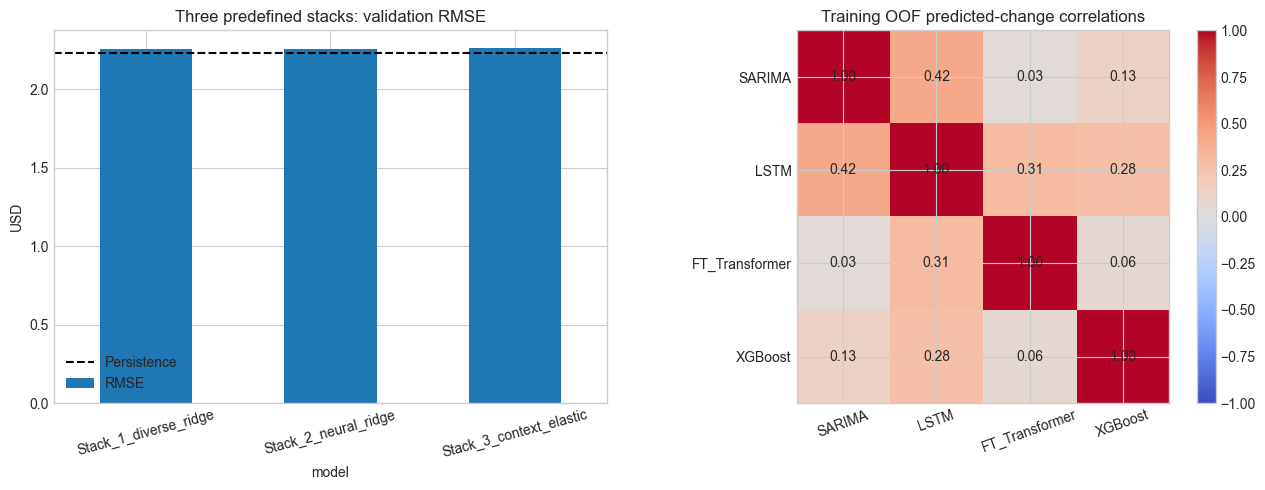

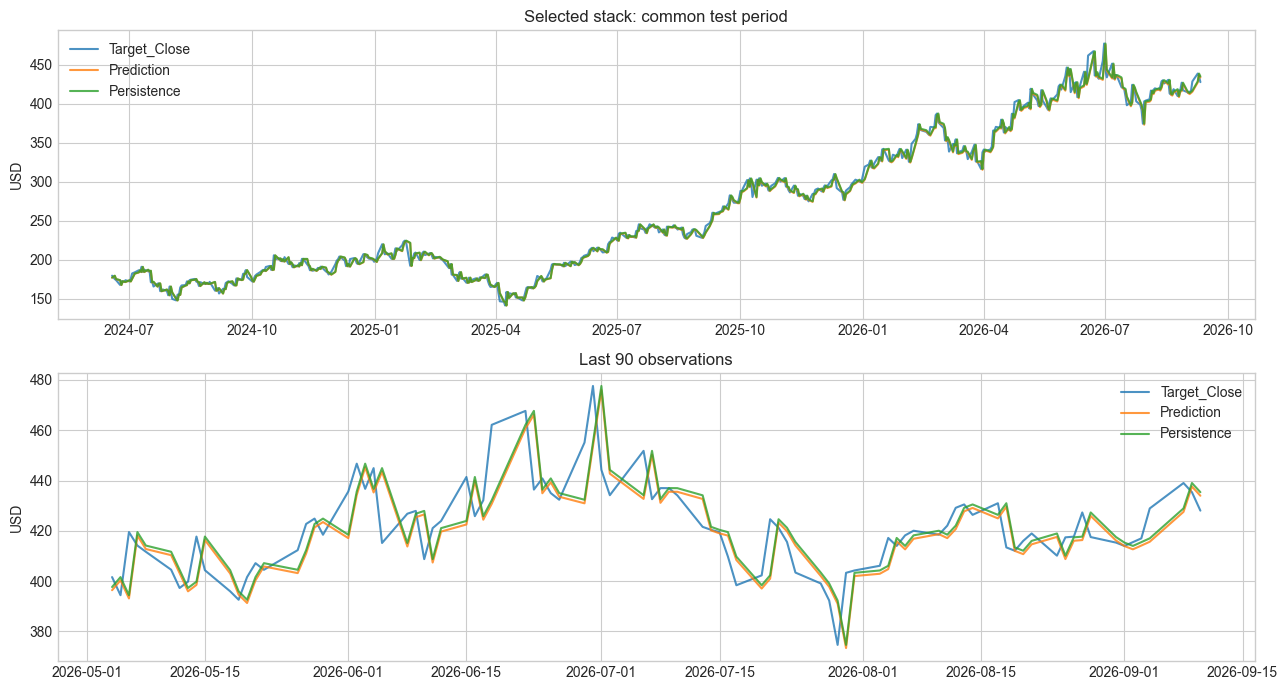

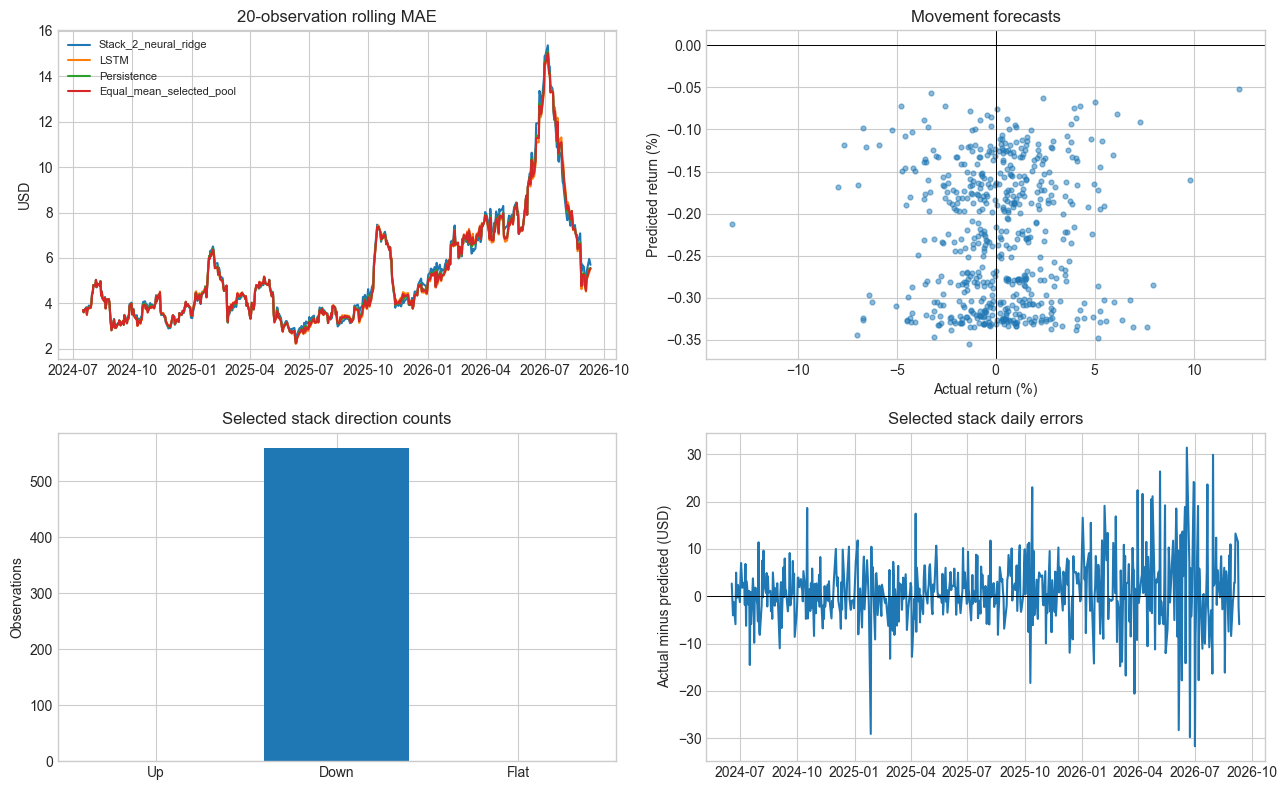

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
validation_metrics.loc[list(STACKS), 'RMSE'].plot.bar(ax=axes[0], rot=15)
axes[0].axhline(validation_metrics.loc['Persistence', 'RMSE'], color='black', linestyle='--', label='Persistence')
axes[0].set(title='Three predefined stacks: validation RMSE', ylabel='USD'); axes[0].legend()
corr = train_oof.corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[1].set(xticks=range(4), yticks=range(4), xticklabels=BASE_NAMES, yticklabels=BASE_NAMES,
            title='Training OOF predicted-change correlations')
axes[1].tick_params(axis='x', rotation=20)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=axes[1])
finish_plot('01_validation_and_diversity')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, frame in [(axes[0], test_export), (axes[1], test_export.tail(90))]:
    for column in ['Target_Close', 'Prediction', 'Persistence']:
        ax.plot(frame['Target_Date'], frame[column], label=column, alpha=0.8)
    ax.set_ylabel('USD'); ax.legend()
axes[0].set_title('Selected stack: common test period')
axes[1].set_title('Last 90 observations')
finish_plot('02_test_prices')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for name in [SELECTED_STACK, BEST_BASE, 'Persistence', 'Equal_mean_selected_pool']:
    errors = pd.Series(np.abs(test['Target_Close'].to_numpy() - test_prices[name])).rolling(20).mean()
    axes[0, 0].plot(test['Target_Date'], errors, label=name)
axes[0, 0].set(title='20-observation rolling MAE', ylabel='USD'); axes[0, 0].legend(fontsize=8)
axes[0, 1].scatter(test_export['Actual_return'] * 100, test_export['Predicted_return'] * 100, s=12, alpha=0.5)
axes[0, 1].axhline(0, color='black', linewidth=0.7); axes[0, 1].axvline(0, color='black', linewidth=0.7)
axes[0, 1].set(title='Movement forecasts', xlabel='Actual return (%)', ylabel='Predicted return (%)')
m = test_metrics.loc[SELECTED_STACK]
axes[1, 0].bar(['Up', 'Down', 'Flat'], [m['Predicted_up'], m['Predicted_down'], m['Predicted_flat']])
axes[1, 0].set(title='Selected stack direction counts', ylabel='Observations')
axes[1, 1].plot(test['Target_Date'], test_export['Error_actual_minus_predicted'])
axes[1, 1].axhline(0, color='black', linewidth=0.7)
axes[1, 1].set(title='Selected stack daily errors', ylabel='Actual minus predicted (USD)')
finish_plot('03_errors_and_directions')


## 11. Save the completed experiment and interpretation

The report must distinguish the chosen stack from persistence, the validation-selected individual model, and a simple average. If the selected stack loses, retain that result. No profitability or statistically significant improvement is inferred from these metrics.

Model weights learned on OOF fits at earlier cutoffs may not transfer perfectly to bases refitted on longer history. Other limitations include a single stock, one outer validation period, fixed base specifications inherited from earlier exploration, correlated forecasts, ordinal calendar inputs, and previously observed historical test data. GPU results may vary slightly across library/hardware versions.


In [12]:
manifest = {
    'run_id': RUN_ID, 'source_file': str(DATA_FILE.relative_to(ROOT)), 'source_sha256': SOURCE_HASH,
    'raw_rows': len(raw), 'aligned_rows': len(data),
    'splits': json.loads(split_summary.to_json(orient='records', date_format='iso')),
    'stacks': STACKS, 'base_settings': SETTINGS, 'transformer_features': TRANSFORMER_FEATURES,
    'xgboost_features': CURATED, 'lstm_features': ['Close'], 'lstm_lookback': SETTINGS['lookback'],
    'n_expanding_folds_each_pass': N_SPLITS, 'initial_history_fraction': 0.40,
    'training_meta_rows': len(train_oof), 'final_meta_rows': len(final_oof),
    'base_target': 'Next-day Close; XGBoost learns dollar change',
    'meta_target': 'Next-day Close minus current Close',
    'selection': locked, 'test_weights': 'Fixed; SARIMA updates state after each realized target',
    'validation_metrics': json.loads(validation_metrics.to_json(orient='index')),
    'test_metrics': json.loads(test_metrics.to_json(orient='index')),
    'reload_check': 'Every base and selected meta; first 20 chronological test rows',
    'gpu': torch.cuda.get_device_name(0),
    'versions': {'python': platform.python_version(), 'torch': torch.__version__, 'xgboost': xgb.__version__,
                 'numpy': np.__version__, 'pandas': pd.__version__, 'sklearn': sklearn.__version__,
                 'statsmodels': statsmodels.__version__},
    'limitations': ['Inherited base specifications are not re-selected inside folds',
                    'Prior validation/test exposure in project development',
                    'Earlier OOF fit distributions differ from final refits',
                    'Single stock and outer validation period; correlated forecasts',
                    'No trading simulation or statistical superiority claim'],
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
m = test_metrics.loc[SELECTED_STACK]
summary = f"""# Chronological stacking experiment

- Compared three fixed stacks on validation; selected **{SELECTED_STACK}**.
- Base specifications: SARIMA, LSTM, FT-Transformer and XGBoost. Shared five-fold expanding OOF predictions; final OOF rebuilt on train + validation.
- Meta-training rows: {len(train_oof)} initially, {len(final_oof)} for the final refit.
- Selected stack validation RMSE: **${validation_metrics.loc[SELECTED_STACK, 'RMSE']:.4f}**.
- Test RMSE **${m['RMSE']:.4f}**, MAE **${m['MAE']:.4f}**, MAPE **{m['MAPE_pct']:.3f}%**, R² **{m['R2']:.5f}**.
- Test persistence RMSE **${test_metrics.loc['Persistence', 'RMSE']:.4f}**; stack improvement **{m['RMSE_skill_pct']:.3f}%** (negative means worse).
- Validation-selected individual reference: **{BEST_BASE}**, test RMSE **${test_metrics.loc[BEST_BASE, 'RMSE']:.4f}**.
- Equal mean of selected base pool: test RMSE **${test_metrics.loc['Equal_mean_selected_pool', 'RMSE']:.4f}**.
- Direction accuracy **{m['Direction_accuracy_pct']:.2f}%**, always-up reference **{m['Always_up_accuracy_pct']:.2f}%**.
- Predicted up/down/flat: {int(m['Predicted_up'])}/{int(m['Predicted_down'])}/{int(m['Predicted_flat'])}.
- Saved-model reload checks passed. Final models are saved at the train + validation cutoff.
- Limitations: fixed specifications inherited from prior exploration, prior test exposure, one stock/validation period, OOF-to-refit distribution shifts. No trading profitability or statistical superiority established.
"""
(RUN_DIR / 'summary.md').write_text(summary, encoding='utf-8')
(RUN_DIR.parent / 'latest_run.json').write_text(json.dumps({
    'run_id': RUN_ID, 'directory': str(RUN_DIR.relative_to(ROOT))}, indent=2), encoding='utf-8')
display(Markdown(summary))


# Chronological stacking experiment

- Compared three fixed stacks on validation; selected **Stack_2_neural_ridge**.
- Base specifications: SARIMA, LSTM, FT-Transformer and XGBoost. Shared five-fold expanding OOF predictions; final OOF rebuilt on train + validation.
- Meta-training rows: 1563 initially, 1898 for the final refit.
- Selected stack validation RMSE: **$2.2565**.
- Test RMSE **$7.4811**, MAE **$5.2860**, MAPE **1.984%**, R² **0.99335**.
- Test persistence RMSE **$7.4013**; stack improvement **-1.079%** (negative means worse).
- Validation-selected individual reference: **LSTM**, test RMSE **$7.3915**.
- Equal mean of selected base pool: test RMSE **$7.3884**.
- Direction accuracy **46.69%**, always-up reference **53.13%**.
- Predicted up/down/flat: 0/559/0.
- Saved-model reload checks passed. Final models are saved at the train + validation cutoff.
- Limitations: fixed specifications inherited from prior exploration, prior test exposure, one stock/validation period, OOF-to-refit distribution shifts. No trading profitability or statistical superiority established.
